# Ramsey Analysis
Load a pre-parsed `xarray.Dataset` from an `.h5` file and run `RamseyAnalyzer`.

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from scqat.protocols.ramsey import RamseyAnalyzer
from scqat.parsers.xarray_h5_parser import load_xarray_h5
from scqat.parsers.qualibrate_parser import repetition_data

## 1. Configuration

In [ ]:
# Path to the pre-parsed xarray Dataset stored as NetCDF4/HDF5
H5_PATH = r"d:\github\LCHQMDriver\data\QPU_project\2026-04-02\#1047_LCH_Ramsey_213050\ds_raw.h5"

# Optional: directory for saving outputs (set to None to skip saving)
OUTPUT_DIR = None #r"d:\github\LCHQMDriver\data\QPU_project\2026-04-02\#1047_LCH_Ramsey_213050"

# Name of the variable in the dataset to use as the signal
# Common choices: "state", "I"
SIGNAL_VAR = "I"

# Optional analysis kwargs
ANALYSIS_KWARGS = {}

    # "force_model": "single",  # force single damped oscillation    # "force_model": "beat",    # force damped beat (two frequencies)

## 2. Load Dataset

In [3]:
dataset = load_xarray_h5(H5_PATH)
dataset

<xarray.Dataset> Size: 2kB
Dimensions:    (idle_time: 100, qubit: 1)
Coordinates:
  * idle_time  (idle_time) int32 400B 16 620 1224 1832 ... 58788 59392 60000
  * qubit      (qubit) object 8B 'q1'
Data variables:
    I          (qubit, idle_time) float64 800B 0.0005022 0.001321 ... 5.458e-05
    Q          (qubit, idle_time) float64 800B -0.001241 -0.001169 ... -0.001191

In [ ]:

# Split by qubit and pick the first one
sq_data = repetition_data(dataset)[0]

# Rename the chosen variable to 'signal' so the analyzer can find it
if SIGNAL_VAR != 'signal' and SIGNAL_VAR in sq_data:
    sq_data = sq_data.rename({SIGNAL_VAR: 'signal'})

sq_data

<xarray.Dataset> Size: 2kB
Dimensions:    (idle_time: 100)
Coordinates:
  * idle_time  (idle_time) int32 400B 16 620 1224 1832 ... 58788 59392 60000
    qubit      <U2 8B 'q1'
Data variables:
    signal     (idle_time) float64 800B 0.0005022 0.001321 ... 5.458e-05
    Q          (idle_time) float64 800B -0.001241 -0.001169 ... -0.001191

## 3. Run Analysis

In [5]:
analyzer = RamseyAnalyzer()
results, figs = analyzer.analyze(
    sq_data,
    output_dir=OUTPUT_DIR,
    **ANALYSIS_KWARGS,
)

## 4. Display Figures

--- time_domain ---


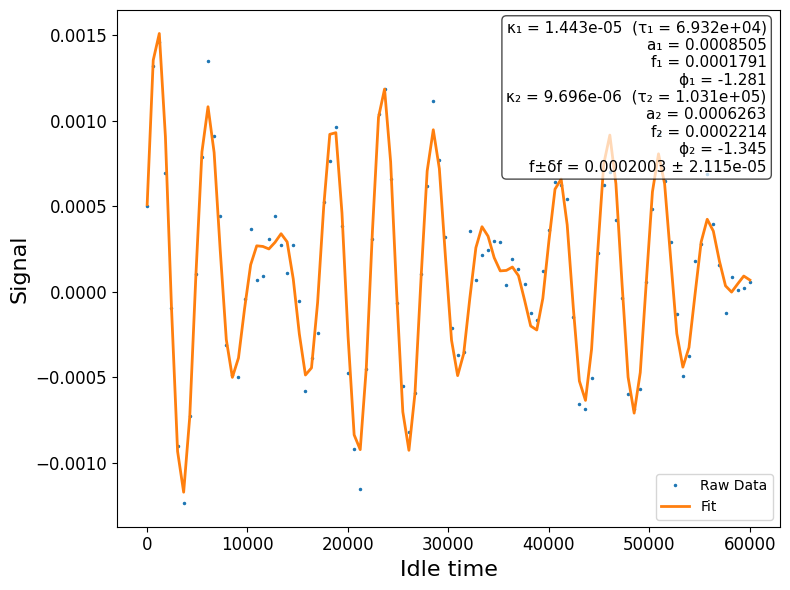

--- fft_spectrum ---


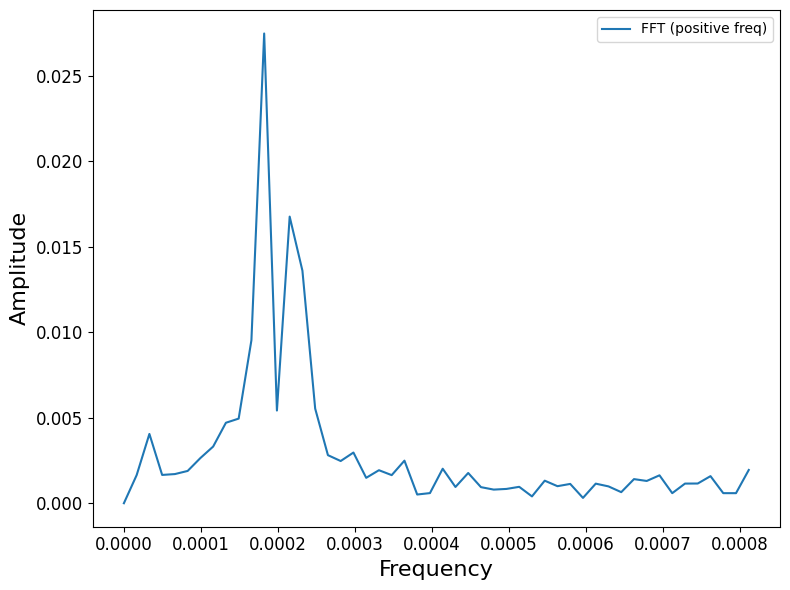

In [6]:
for name, fig in figs.items():
    print(f"--- {name} ---")
    display(fig)
    plt.close(fig)

## 5. Inspect Results

In [7]:
print(f"Model type: {results['model_type']}")
print(f"\nf_1 = {results['f_1']:.6g}")
print(f"kappa_1 = {results['kappa_1']:.6g}  (tau_1 = {results['tau_1']:.6g})")

if results['model_type'] == 'beat':
    print(f"\nf_2 = {results['f_2']:.6g}")
    print(f"kappa_2 = {results['kappa_2']:.6g}  (tau_2 = {results['tau_2']:.6g})")

print(f"\nFit report:\n{results['fit_report']}")

Model type: beat

f_1 = 0.000179125
kappa_1 = 1.44256e-05  (tau_1 = 69321.1)

f_2 = 0.000221429
kappa_2 = 9.69565e-06  (tau_2 = 103139)

Fit report:
[[Model]]
    Model(model_function)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 101
    # data points      = 100
    # variables        = 9
    chi-square         = 1.4847e-06
    reduced chi-square = 1.6315e-08
    Akaike info crit   = -1784.54953
    Bayesian info crit = -1761.10300
    R-squared          = 0.95173223
[[Variables]]
    a_1:      8.5053e-04 +/- 4.6337e-05 (5.45%) (init = 0.02747703)
    kappa_1:  1.4426e-05 +/- 1.9923e-06 (13.81%) (init = 3.333333e-05)
    f_1:      1.7912e-04 +/- 3.2840e-07 (0.18%) (init = 0.0001821192)
    phi_1:   -1.28097852 +/- 0.05625809 (4.39%) (init = 0)
    a_2:      6.2630e-04 +/- 4.4984e-05 (7.18%) (init = 0.01676507)
    kappa_2:  9.6956e-06 +/- 2.3896e-06 (24.65%) (init = 3.333333e-05)
    f_2:      2.2143e-04 +/- 3.7601e-07 (0.17%) (init = 0.0002152318)
    p